In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.head(10)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


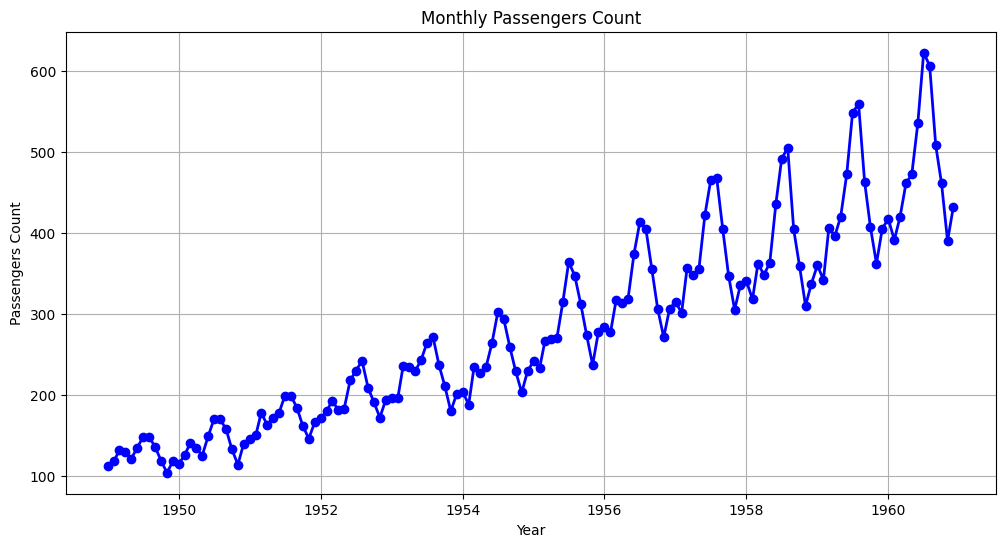

In [3]:
# Creating a line plot
plt.figure(figsize=(12, 6))
plt.plot(df, color='blue', marker='o', linestyle='-', linewidth=2)
plt.title('Monthly Passengers Count')
plt.xlabel('Year')
plt.ylabel('Passengers Count')
plt.grid(True)
plt.show()

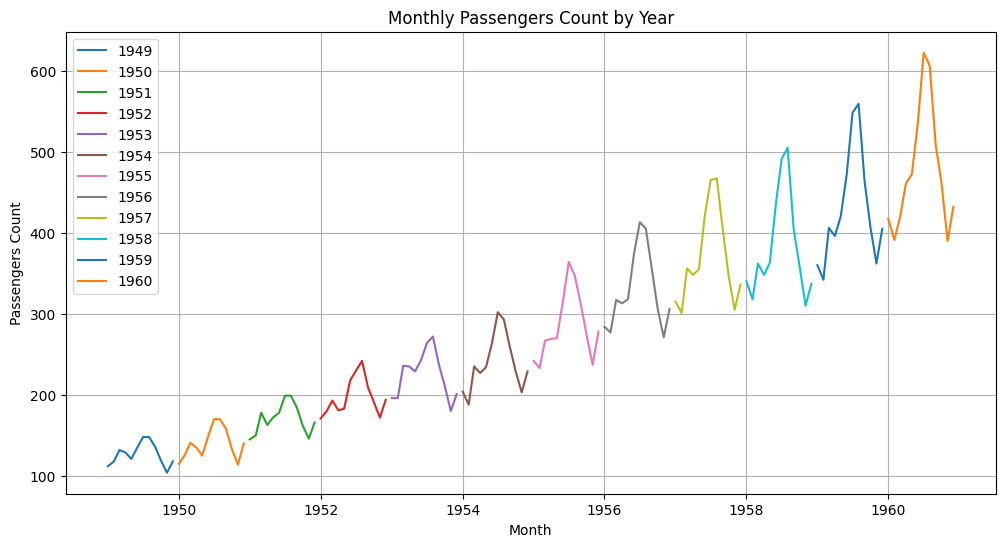

In [4]:
#Extract years from data
years = df.index.year.unique()

#Plotting each year as its own line
plt.figure(figsize=(12,6))
for year in years:
    year_data = df[df.index.year == year]
    plt.plot(year_data['Passengers'], label=year)

plt.title('Monthly Passengers Count by Year')
plt.xlabel('Month')
plt.ylabel('Passengers Count')
plt.legend()
plt.grid(True)
plt.show()

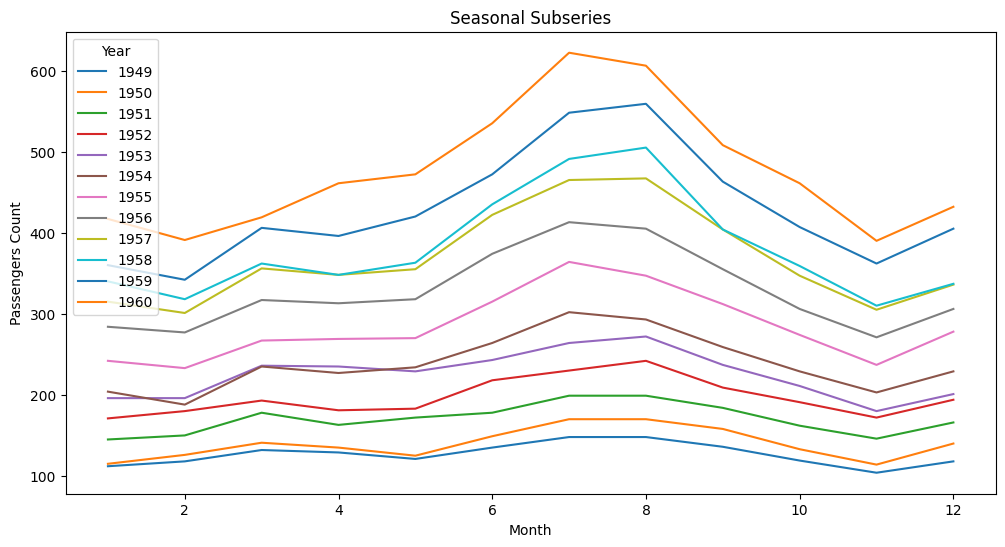

In [5]:
# Plot seasonal subseries
df['Year'] = df.index.year
df['month'] = df.index.month

# Pivot table
table = pd.pivot_table(df, values='Passengers', index=['month'], columns='Year', aggfunc='sum')

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
table.plot(ax=ax, kind='line', legend=True)
plt.title('Seasonal Subseries')
plt.xlabel('Month')
plt.ylabel('Passengers Count')
plt.show()

Text(0, 0.5, 'Density')

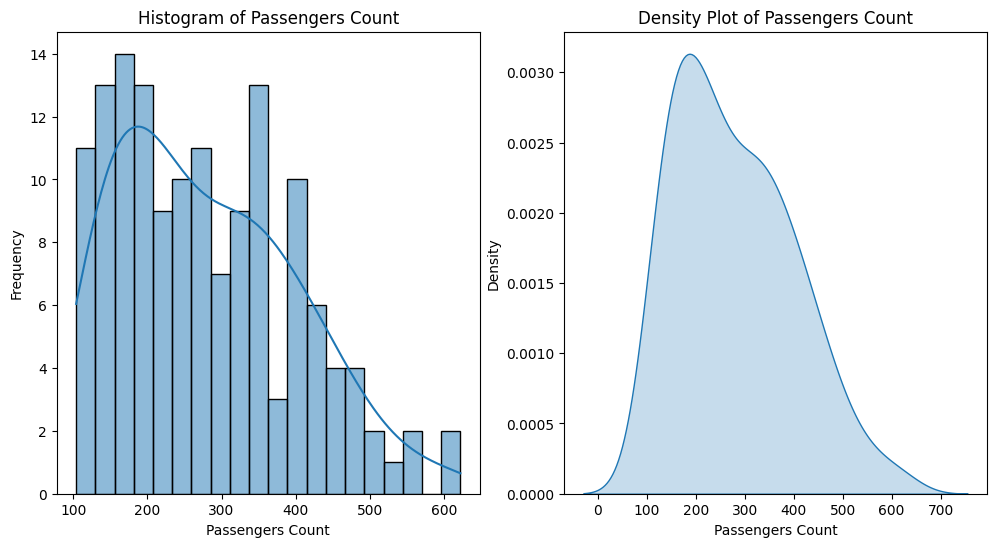

In [6]:
import seaborn as sns

#Histogram
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['Passengers'], bins=20, kde=True)
plt.title('Histogram of Passengers Count')
plt.xlabel('Passengers Count')
plt.ylabel('Frequency')

#Densidad
plt.subplot(1, 2, 2)
sns.kdeplot(df['Passengers'], fill=True)
plt.title('Density Plot of Passengers Count')
plt.xlabel('Passengers Count')
plt.ylabel('Density')

Exercise 1.

Use the Sunspots dataset (https://www.kaggle.com/datasets/robervalt/sunspots) to demonstrate basic concepts of time series

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [9]:
df = pd.read_csv("Sunspots.csv")
df.head()

,Unnamed: 0,Date,Monthly Mean Total Sunspot Number
0,0,1749-01-31,96.7
1,1,1749-02-28,104.3
2,2,1749-03-31,116.7
3,3,1749-04-30,92.8
4,4,1749-05-31,141.7


In [10]:
# Limpieza  y preparación
df.rename(columns={
    'Monthly Mean Total Sunspot Number': 'Sunspots'
}, inplace=True)

# Convertir la columna de fecha a tipo datetime
df['Date'] = pd.to_datetime(df['Date'])

# Poner la fecha como índice de la serie de tiempo
df.set_index('Date', inplace=True)

# Ordenar por fecha por si acaso
df.sort_index(inplace=True)

df.head()

,Unnamed: 0,Sunspots
Date,,
1749-01-31,0,96.7
1749-02-28,1,104.3
1749-03-31,2,116.7
1749-04-30,3,92.8
1749-05-31,4,141.7


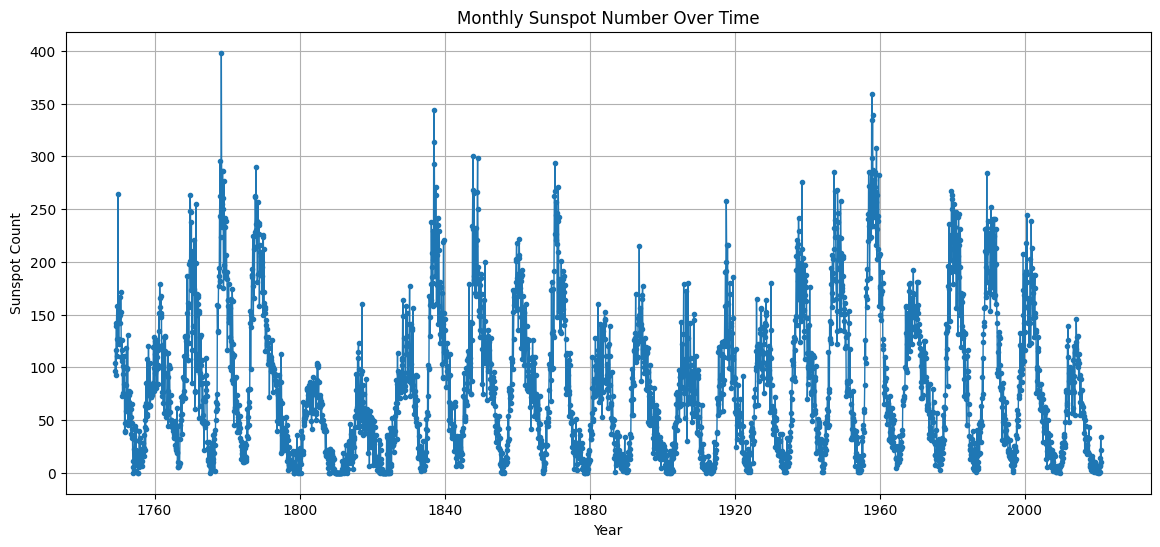

In [11]:
plt.figure(figsize=(14, 6))
plt.plot(df['Sunspots'], marker='.', linestyle='-', linewidth=1)
plt.title('Monthly Sunspot Number Over Time')
plt.xlabel('Year')
plt.ylabel('Sunspot Count')
plt.grid(True)
plt.show()

La gráfica muestra el número mensual de manchas solares desde mediados del siglo XVIII hasta los años recientes. Se observa un patrón cíclico muy marcado, donde los niveles de actividad solar suben y bajan aproximadamente cada 11 años, reflejando el conocido ciclo solar. Durante los picos, el número de manchas solares aumenta significativamente, mientras que en los valles cae casi a cero. Aunque el ciclo se repite, la intensidad de cada máximo varía, mostrando que algunos periodos tuvieron mucha mayor actividad solar que otros. En general, la serie evidencia la naturaleza periódica y variable de la actividad del Sol a lo largo del tiempo.

In [12]:
df['Year'] = df.index.year
df['Month'] = df.index.month

df[['Sunspots', 'Year', 'Month']].head()

,Sunspots,Year,Month
Date,,,
1749-01-31,96.7,1749,1
1749-02-28,104.3,1749,2
1749-03-31,116.7,1749,3
1749-04-30,92.8,1749,4
1749-05-31,141.7,1749,5


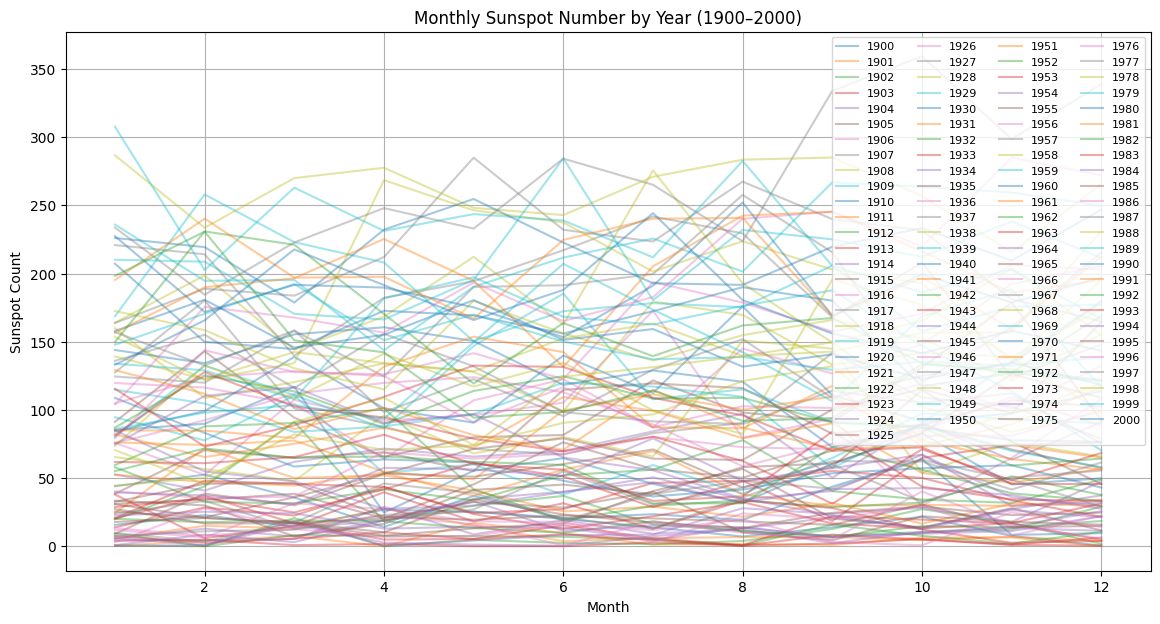

In [13]:
mask = (df.index.year >= 1900) & (df.index.year <= 2000)
df_100y = df.loc[mask]

years = df_100y['Year'].unique()

plt.figure(figsize=(14, 7))
for year in years:
    year_data = df_100y[df_100y['Year'] == year]
    plt.plot(year_data['Month'], year_data['Sunspots'], label=year, alpha=0.4)

plt.title('Monthly Sunspot Number by Year (1900–2000)')
plt.xlabel('Month')
plt.ylabel('Sunspot Count')
plt.grid(True)
plt.legend(ncol=4, fontsize=8)
plt.show()

La gráfica muestra el número mensual de manchas solares para cada año entre 1900 y 2000. Aunque las líneas se sobreponen, se observa un comportamiento muy variable entre años, con meses que pueden tener desde pocos hasta más de 300 recuentos según el ciclo solar activo en ese periodo. No existe un patrón mensual fijo (por ejemplo, un mes que siempre tenga más actividad), sino que la variación depende principalmente del ciclo solar multianual, no del mes del año. En conjunto, la gráfica refleja que cada año sigue una forma distinta dentro del ciclo de 11 años, generando esta superposición densa y mostrando la alta variabilidad natural de la actividad solar.

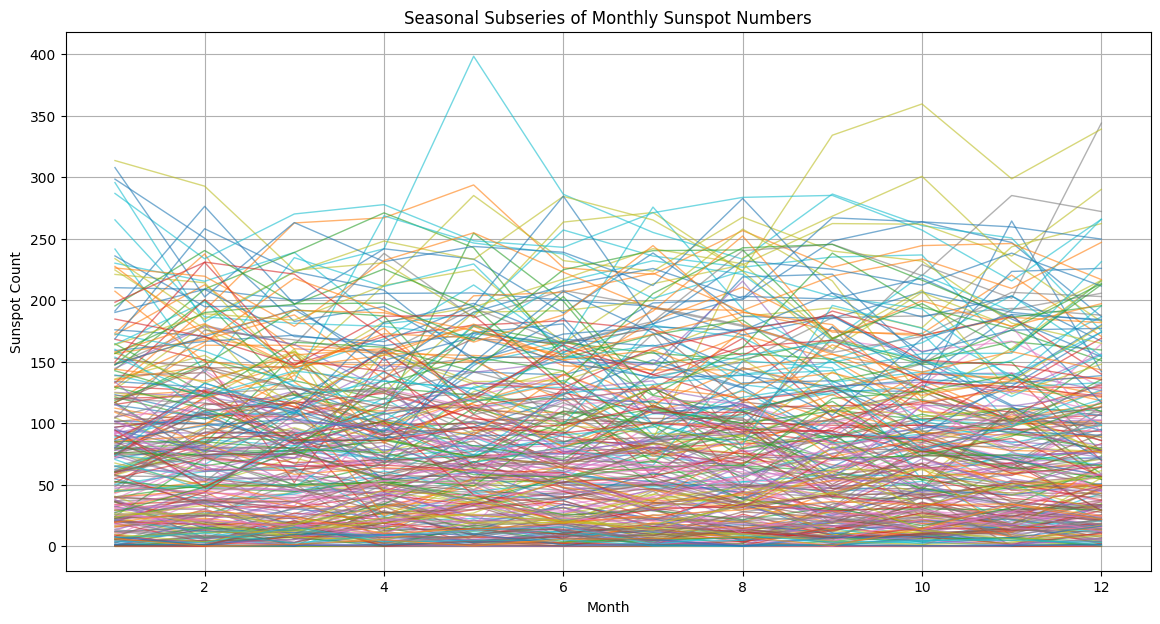

In [14]:
table = pd.pivot_table(
    df,
    values='Sunspots',
    index='Month',
    columns='Year',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(14, 7))
table.plot(ax=ax, legend=False, linewidth=1, alpha=0.6)
plt.title('Seasonal Subseries of Monthly Sunspot Numbers')
plt.xlabel('Month')
plt.ylabel('Sunspot Count')
plt.grid(True)
plt.show()

La gráfica muestra los valores mensuales de manchas solares agrupados por mes a lo largo de todos los años del registro. Aunque las líneas se traslapan fuertemente, se observa que no existe una estacionalidad mensual definida: es decir, ningún mes del año presenta consistentemente valores más altos o más bajos de actividad solar. En cambio, la gran variabilidad entre líneas refleja que el comportamiento mensual depende principalmente del punto del ciclo solar de 11 años, no del mes específico. Esto confirma que las manchas solares no siguen un patrón estacionario mensual, sino un patrón cíclico de largo plazo.

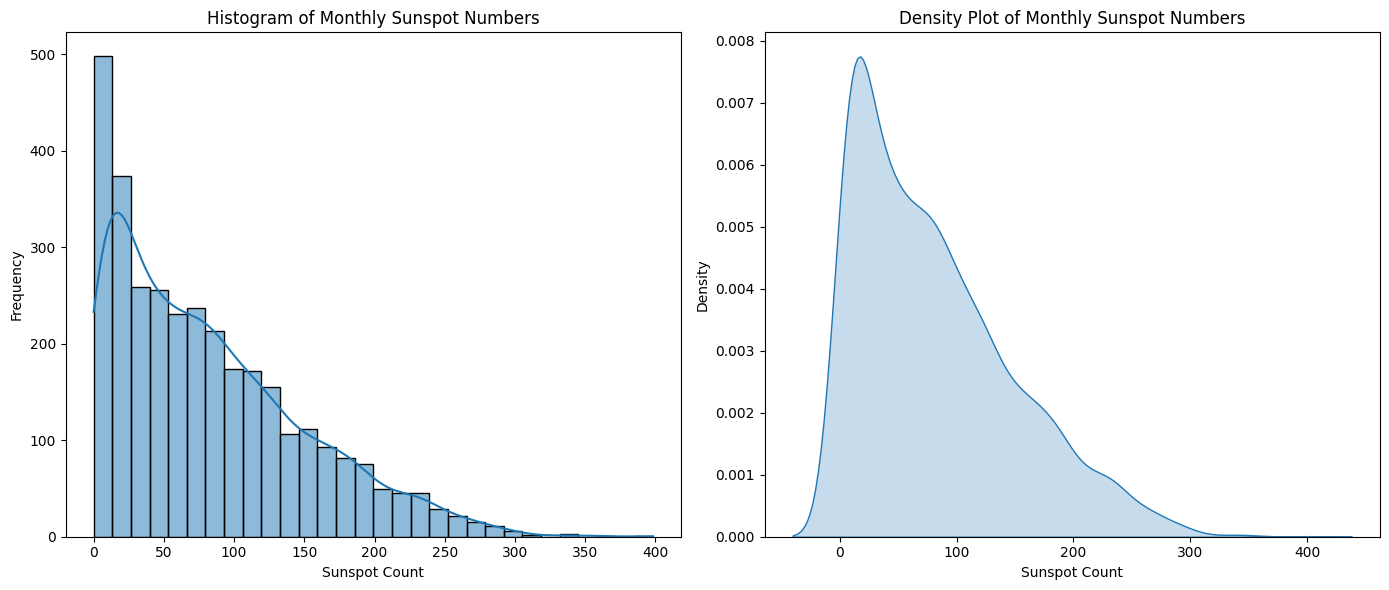

In [15]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['Sunspots'].dropna(), bins=30, kde=True)
plt.title('Histogram of Monthly Sunspot Numbers')
plt.xlabel('Sunspot Count')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.kdeplot(df['Sunspots'].dropna(), fill=True)
plt.title('Density Plot of Monthly Sunspot Numbers')
plt.xlabel('Sunspot Count')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

Ambas gráficas muestran la distribución de los números mensuales de manchas solares. El histograma revela que la mayoría de los valores se concentran en rangos bajos (entre 0 y 50 manchas), mientras que las frecuencias disminuyen gradualmente conforme aumentan los conteos. La gráfica de densidad confirma esta forma asimétrica y sesgada a la derecha, con una cola larga hacia valores altos. Esto significa que, aunque en la mayoría de los meses la actividad solar es moderada o baja, existen periodos con picos muy intensos que ocurren con menor frecuencia, reflejando la naturaleza variable y cíclica de la actividad solar.

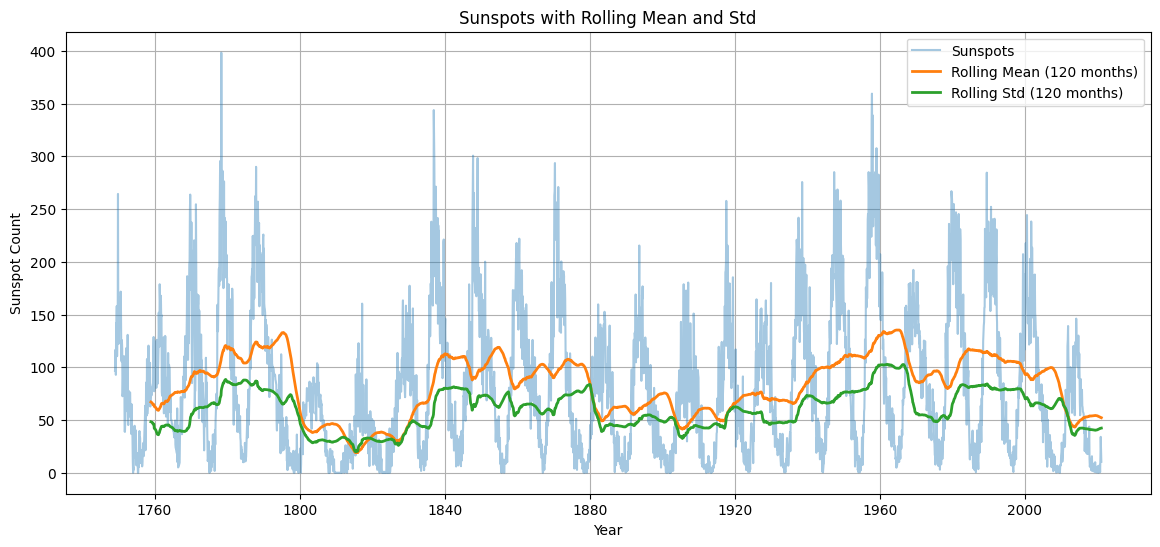

In [16]:
window = 120
rolling_mean = df['Sunspots'].rolling(window=window).mean()
rolling_std = df['Sunspots'].rolling(window=window).std()

plt.figure(figsize=(14, 6))
plt.plot(df['Sunspots'], alpha=0.4, label='Sunspots')
plt.plot(rolling_mean, linewidth=2, label=f'Rolling Mean ({window} months)')
plt.plot(rolling_std, linewidth=2, label=f'Rolling Std ({window} months)')
plt.title('Sunspots with Rolling Mean and Std')
plt.xlabel('Year')
plt.ylabel('Sunspot Count')
plt.legend()
plt.grid(True)
plt.show()

La gráfica muestra la serie histórica de manchas solares junto con su media móvil y desviación estándar móvil calculadas a 120 meses (10 años). La línea de la media móvil (naranja) suaviza la variabilidad mensual y permite ver claramente los ciclos de actividad solar: cada 10–12 años se observan aumentos y disminuciones en la actividad. La desviación estándar móvil (verde) indica cómo fluctúa la variabilidad dentro de cada ciclo; esta tiende a aumentar cuando el Sol está en periodos de alta actividad y a disminuir en los mínimos solares. En conjunto, las líneas suavizadas permiten visualizar de manera más clara los patrones cíclicos y los cambios en la intensidad y variabilidad de la actividad solar a lo largo de los siglos.

Exercise 2.

Use the Unemployment in America dataset(https://www.kaggle.com/datasets/justin2028/unemployment-in-america-per-us-state)

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

plt.style.use("default")

In [22]:
df = pd.read_csv("Unemployment_in_America.csv")
df.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,1,Alabama,1976,1,"2,605,000","1,484,555",57.0,"1,386,023",53.2,"98,532",6.6
1,2,Alaska,1976,1,"232,000","160,183",69.0,"148,820",64.1,"11,363",7.1
2,4,Arizona,1976,1,"1,621,000","964,120",59.5,"865,871",53.4,"98,249",10.2
3,5,Arkansas,1976,1,"1,536,000","889,044",57.9,"824,395",53.7,"64,649",7.3
4,6,California,1976,1,"15,621,000","9,774,280",62.6,"8,875,685",56.8,"898,595",9.2


In [23]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29892 entries, 0 to 29891
Data columns (total 11 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   FIPS Code                                                  29892 non-null  int64  
 1   State/Area                                                 29892 non-null  object 
 2   Year                                                       29892 non-null  int64  
 3   Month                                                      29892 non-null  int64  
 4   Total Civilian Non-Institutional Population in State/Area  29892 non-null  object 
 5   Total Civilian Labor Force in State/Area                   29892 non-null  object 
 6   Percent (%) of State/Area's Population                     29892 non-null  float64
 7   Total Employment in State/Area                             29892 non-null  object 
 8   Percen

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area
count,29892.000000,29892,29892.000000,29892.00000,29892,29892,29892.000000,29892,29892.000000,29892,29892.000000
unique,NaN,53,NaN,NaN,25836,29755,NaN,29743,NaN,28261,NaN
top,NaN,Alabama,NaN,NaN,"483,000","307,752",NaN,"337,853",NaN,"21,663",NaN
freq,NaN,564,NaN,NaN,39,2,NaN,4,NaN,4,NaN
mean,990.830189,NaN,1999.000000,6.50000,NaN,NaN,65.516202,NaN,61.670417,NaN,5.920788
std,6935.157218,NaN,13.564887,3.45211,NaN,NaN,4.304355,NaN,4.739074,NaN,2.207521
min,1.000000,NaN,1976.000000,1.00000,NaN,NaN,51.000000,NaN,41.600000,NaN,1.900000
25%,17.000000,NaN,1987.000000,3.75000,NaN,NaN,62.800000,NaN,58.600000,NaN,4.300000
50%,30.000000,NaN,1999.000000,6.50000,NaN,NaN,65.900000,NaN,61.800000,NaN,5.500000
75%,42.000000,NaN,2011.000000,9.25000,NaN,NaN,68.500000,NaN,65.100000,NaN,7.100000


In [24]:
df.isna().sum()

,0
FIPS Code,0
State/Area,0
Year,0
Month,0
Total Civilian Non-Institutional Population in State/Area,0
Total Civilian Labor Force in State/Area,0
Percent (%) of State/Area's Population,0
Total Employment in State/Area,0
Percent (%) of Labor Force Employed in State/Area,0
Total Unemployment in State/Area,0


In [25]:
num_cols = df.select_dtypes(include=np.number).columns
df_num = df[num_cols]

df_num.head()

,FIPS Code,Year,Month,Percent (%) of State/Area's Population,Percent (%) of Labor Force Employed in State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,1,1976,1,57.0,53.2,6.6
1,2,1976,1,69.0,64.1,7.1
2,4,1976,1,59.5,53.4,10.2
3,5,1976,1,57.9,53.7,7.3
4,6,1976,1,62.6,56.8,9.2


In [26]:
imputer = IterativeImputer(random_state=42)

df_num_imputed = imputer.fit_transform(df_num)
df_num_imputed = pd.DataFrame(df_num_imputed, columns=num_cols)

df_num_imputed.head()

,FIPS Code,Year,Month,Percent (%) of State/Area's Population,Percent (%) of Labor Force Employed in State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,1.0,1976.0,1.0,57.0,53.2,6.6
1,2.0,1976.0,1.0,69.0,64.1,7.1
2,4.0,1976.0,1.0,59.5,53.4,10.2
3,5.0,1976.0,1.0,57.9,53.7,7.3
4,6.0,1976.0,1.0,62.6,56.8,9.2


In [27]:
df_imputed = df.copy()
df_imputed[num_cols] = df_num_imputed

df_imputed.head()

,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area
0,1.0,Alabama,1976.0,1.0,"2,605,000","1,484,555",57.0,"1,386,023",53.2,"98,532",6.6
1,2.0,Alaska,1976.0,1.0,"232,000","160,183",69.0,"148,820",64.1,"11,363",7.1
2,4.0,Arizona,1976.0,1.0,"1,621,000","964,120",59.5,"865,871",53.4,"98,249",10.2
3,5.0,Arkansas,1976.0,1.0,"1,536,000","889,044",57.9,"824,395",53.7,"64,649",7.3
4,6.0,California,1976.0,1.0,"15,621,000","9,774,280",62.6,"8,875,685",56.8,"898,595",9.2


In [28]:
df.isna().sum(), df_imputed.isna().sum()

(FIPS Code                                                    0
 State/Area                                                   0
 Year                                                         0
 Month                                                        0
 Total Civilian Non-Institutional Population in State/Area    0
 Total Civilian Labor Force in State/Area                     0
 Percent (%) of State/Area's Population                       0
 Total Employment in State/Area                               0
 Percent (%) of Labor Force Employed in State/Area            0
 Total Unemployment in State/Area                             0
 Percent (%) of Labor Force Unemployed in State/Area          0
 dtype: int64,
 FIPS Code                                                    0
 State/Area                                                   0
 Year                                                         0
 Month                                                        0
 Total Civilian Non-Insti

In [31]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

In [33]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10,4)

In [32]:
def plot_series(s, title):
  s.plot()
  plt.title(title)
  plt.xlabel("Time")
  plt.ylabel("Value")
  plt.grid(True)
  plt.show()

def adf_test(x):
  res = adfuller(x, autolag="AIC")
  keys = ['test_stat', 'pvalue', 'lags', 'nobs', 'crit_values', 'icbest']
  return dict(zip(keys,[res[0], res[1], res[3], res[4], res[5]]))

def kpss_test(x, regression='c', nlags="auto"):
  stat, pval, lags, crit = kpss(x, regression=regression, nlags=nlags)
  return {"test_stat": stat, "pvalue": pval, "lags": lags, "crit_values": crit, "regression": regression}

def print_test(x, name="series"):
  print(f"Test {name}")
  a = adf_test(x)
  print(f"ADF Statistic: {a['test_stat']:.3f} p={a['pvalue']}")
  try:
    k = kpss_test(x)
    print(f"KPSS: stat={k['test_stat']:.3f} p={k['pvalue']}")
  except:
    print("KPSS test failed")

def rolling_mean_var(s, window=24, title="Rolling Mean & Var"):
  rolling_mean = s.rolling(window).mean()
  rolling_var = s.rolling(window).var()
  fig, ax = plt.subplots(2, 1, figsize=(10, 6))
  ax[0].plot(s, label="Original")
  ax[0].plot(rolling_mean, label="Rolling Mean")
  ax[0].legend()
  ax[0].set_title(title + "- mean")
  ax[1].plot(rolling_var, label="Rolling Var")
  ax[1].legend()
  ax[1].set_title(title + "- var")
  plt.show()


In [34]:
n = 240  # months
t =  np.arange(n)

# Stationary: white noise
white_noise = pd.Series(np.random.normal(0, 1, n))

trend = 0.02 * t
trended = pd.Series(trend + np.random.normal(0, 1, n))

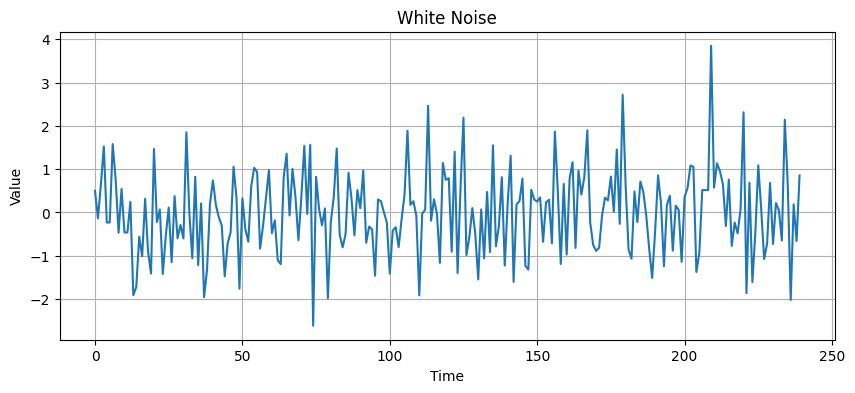

Test White Noise
ADF Statistic: -16.112 p=5.006520467194035e-29
KPSS: stat=0.298 p=0.1


/tmp/ipython-input-2085152180.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(x, regression=regression, nlags=nlags)


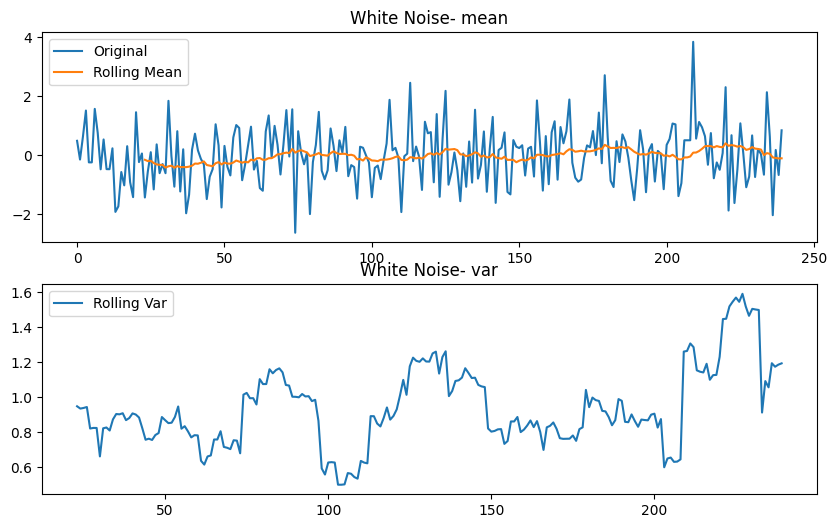

In [35]:
plot_series(white_noise, "White Noise")
print_test(white_noise, "White Noise")
rolling_mean_var(white_noise, window=24, title="White Noise")

In [42]:
print(df['State/Area'].unique())
us_unemployment = df[df['State/Area'] == 'California'].copy() # Filter for California
display(us_unemployment.head())

['Alabama' 'Alaska' 'Arizona' 'Arkansas' 'California' 'Los Angeles County'
 'Colorado' 'Connecticut' 'Delaware' 'District of Columbia' 'Florida'
 'Georgia' 'Hawaii' 'Idaho' 'Illinois' 'Indiana' 'Iowa' 'Kansas'
 'Kentucky' 'Louisiana' 'Maine' 'Maryland' 'Massachusetts' 'Michigan'
 'Minnesota' 'Mississippi' 'Missouri' 'Montana' 'Nebraska' 'Nevada'
 'New Hampshire' 'New Jersey' 'New Mexico' 'New York' 'New York city'
 'North Carolina' 'North Dakota' 'Ohio' 'Oklahoma' 'Oregon' 'Pennsylvania'
 'Rhode Island' 'South Carolina' 'South Dakota' 'Tennessee' 'Texas' 'Utah'
 'Vermont' 'Virginia' 'Washington' 'West Virginia' 'Wisconsin' 'Wyoming']


,FIPS Code,State/Area,Year,Month,Total Civilian Non-Institutional Population in State/Area,Total Civilian Labor Force in State/Area,Percent (%) of State/Area's Population,Total Employment in State/Area,Percent (%) of Labor Force Employed in State/Area,Total Unemployment in State/Area,Percent (%) of Labor Force Unemployed in State/Area
4,6,California,1976,1,"15,621,000","9,774,280",62.6,"8,875,685",56.8,"898,595",9.2
57,6,California,1976,2,"15,657,000","9,768,885",62.4,"8,871,553",56.7,"897,332",9.2
110,6,California,1976,3,"15,694,000","9,768,531",62.2,"8,875,700",56.6,"892,831",9.1
163,6,California,1976,4,"15,731,000","9,789,023",62.2,"8,902,662",56.6,"886,361",9.1
216,6,California,1976,5,"15,768,000","9,821,255",62.3,"8,938,559",56.7,"882,696",9.0


In [44]:
# Combine 'Year' and 'Month' columns to create a datetime index
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))
df.set_index('Date', inplace=True)

In [45]:
# Convert 'Total Unemployment in State/Area' to numeric, coercing errors
df['Total Unemployment in State/Area'] = df['Total Unemployment in State/Area'].astype(str).str.replace(r'\D', '', regex=True)
df['Total Unemployment in State/Area'] = pd.to_numeric(df['Total Unemployment in State/Area'], errors='coerce').fillna(0)

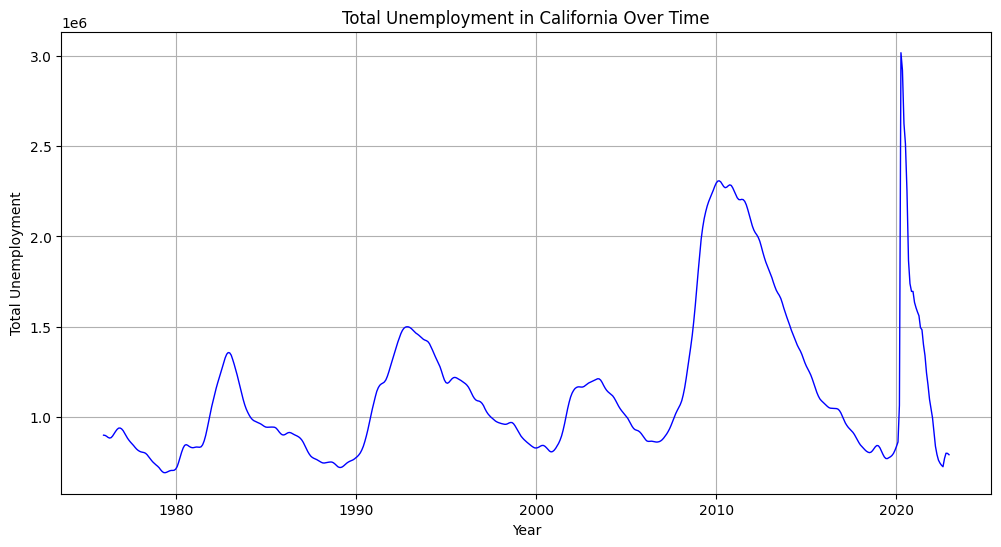

In [46]:
# Creating a line plot for the total unemployment in California
california_unemployment = df[df['State/Area'] == 'California'].copy() # Filter for California
plt.figure(figsize=(12,6))
plt.plot(california_unemployment['Total Unemployment in State/Area'], color='blue', linestyle='-', linewidth=1)
plt.title('Total Unemployment in California Over Time')
plt.xlabel('Year')
plt.ylabel('Total Unemployment')
plt.grid(True)
plt.show()

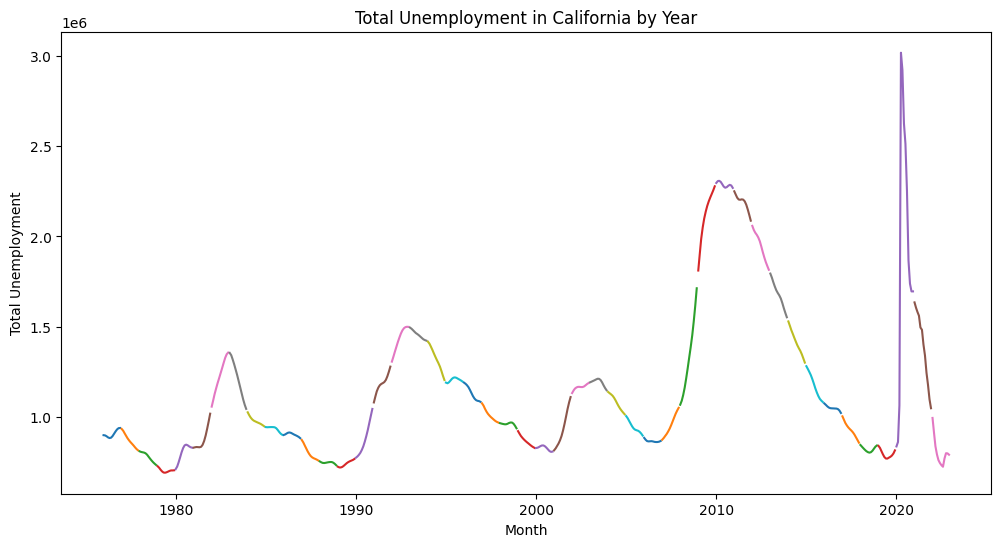

In [47]:
# Filter for California data
california_unemployment = df[df['State/Area'] == 'California'].copy()

# Extract years from data
years_unemployment = california_unemployment.index.year.unique()

# Plotting each year as its own line
plt.figure(figsize=(12,6))
for year in years_unemployment:
  year_data_unemployment = california_unemployment[california_unemployment.index.year == year]
  plt.plot(year_data_unemployment['Total Unemployment in State/Area'], label=year)

plt.title('Total Unemployment in California by Year')
plt.xlabel('Month')
plt.ylabel('Total Unemployment')
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

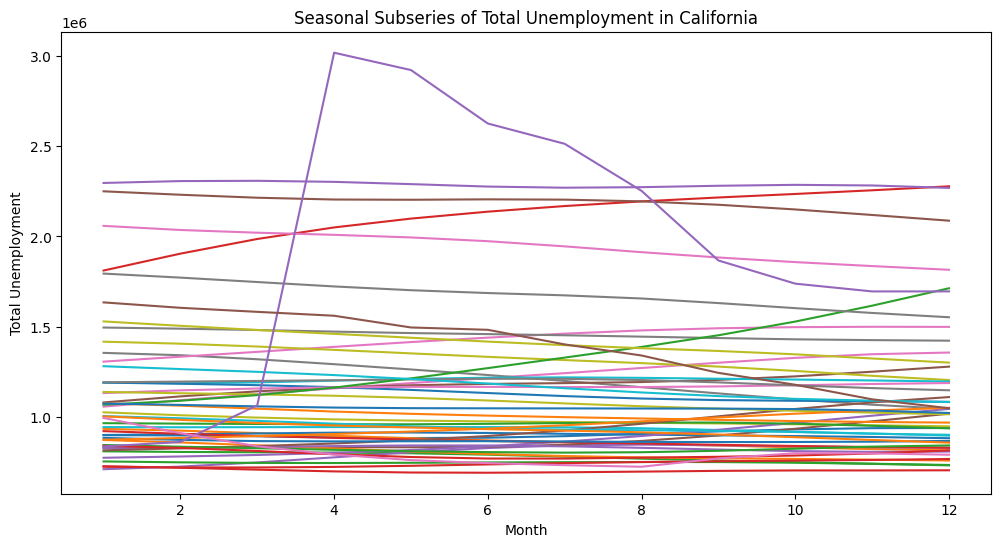

In [48]:
# Filter for California data
california_unemployment = df[df['State/Area'] == 'California'].copy()

# Plot seasonal subseries
california_unemployment['Year'] = california_unemployment.index.year
california_unemployment['month'] = california_unemployment.index.month

# Pivot table
table_unemployment = pd.pivot_table(california_unemployment,
                       values='Total Unemployment in State/Area',
                       index=['month'],
                       columns='Year',
                       aggfunc='sum')

# Plot de series
fig, ax = plt.subplots(figsize=(12,6))
table_unemployment.plot(ax=ax, kind='line', legend=False)
ax.set_xlabel('Month')
ax.set_ylabel('Total Unemployment')
ax.set_title('Seasonal Subseries of Total Unemployment in California')
plt.show()

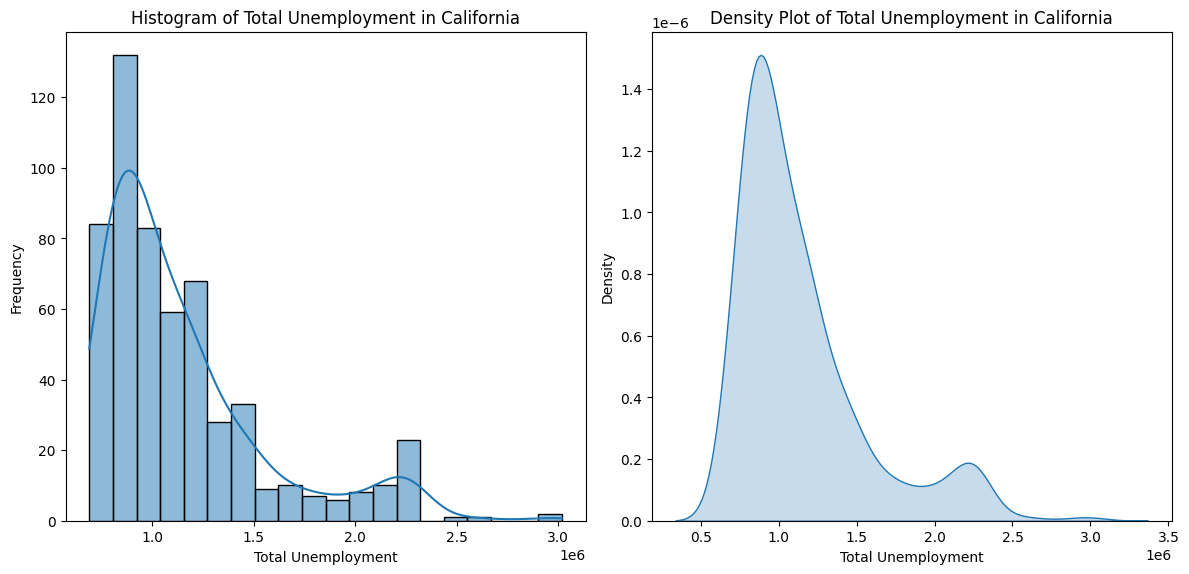

In [49]:
# Filter for California data
california_unemployment = df[df['State/Area'] == 'California'].copy()

# Histogram
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(california_unemployment['Total Unemployment in State/Area'], bins=20, kde=True)
plt.title('Histogram of Total Unemployment in California')
plt.xlabel('Total Unemployment')
plt.ylabel('Frequency')

# Density
plt.subplot(1,2,2)
sns.kdeplot(california_unemployment['Total Unemployment in State/Area'], fill=True)
plt.title('Density Plot of Total Unemployment in California')
plt.xlabel('Total Unemployment')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [50]:
# Display the first few non-numeric values in the 'Total Unemployment in State/Area' column
non_numeric_values = df[pd.to_numeric(df['Total Unemployment in State/Area'], errors='coerce').isna()]['Total Unemployment in State/Area'].unique()
print("Example non-numeric values in 'Total Unemployment in State/Area':")
display(non_numeric_values)

Example non-numeric values in 'Total Unemployment in State/Area':


array([], dtype=int64)

In [51]:
# Calculate total unemployment for the United States by summing across states for each date
us_total_unemployment = df.groupby('Date')['Total Unemployment in State/Area'].sum()

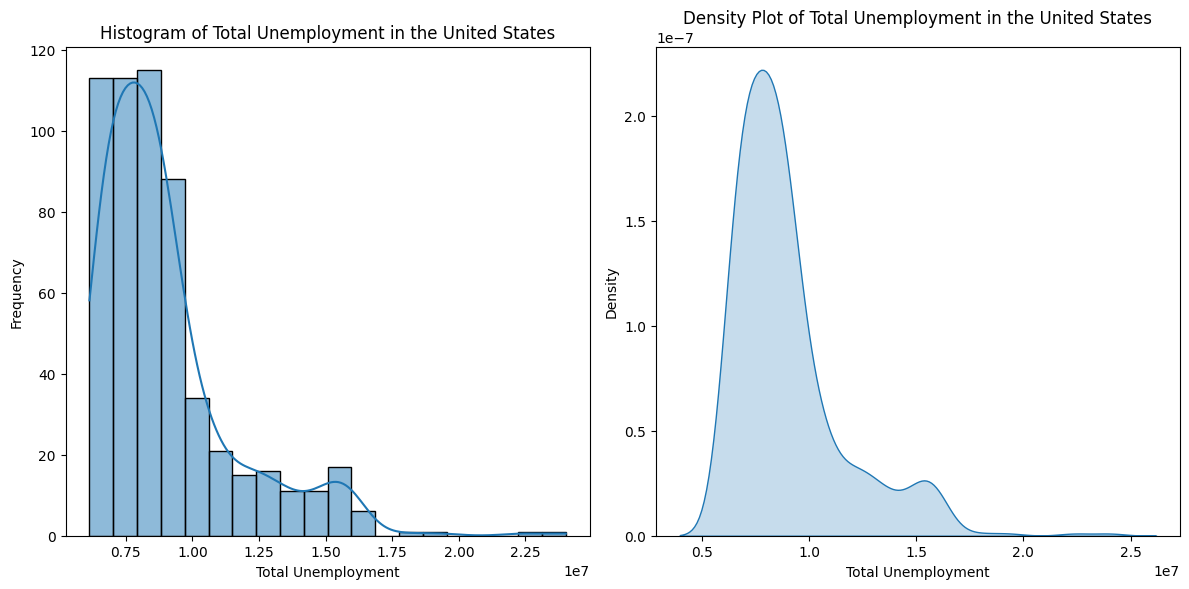

In [52]:
# Histogram and Density plots in subplots
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(us_total_unemployment, bins=20, kde=True)
plt.title('Histogram of Total Unemployment in the United States')
plt.xlabel('Total Unemployment')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
sns.kdeplot(us_total_unemployment, fill=True)
plt.title('Density Plot of Total Unemployment in the United States')
plt.xlabel('Total Unemployment')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

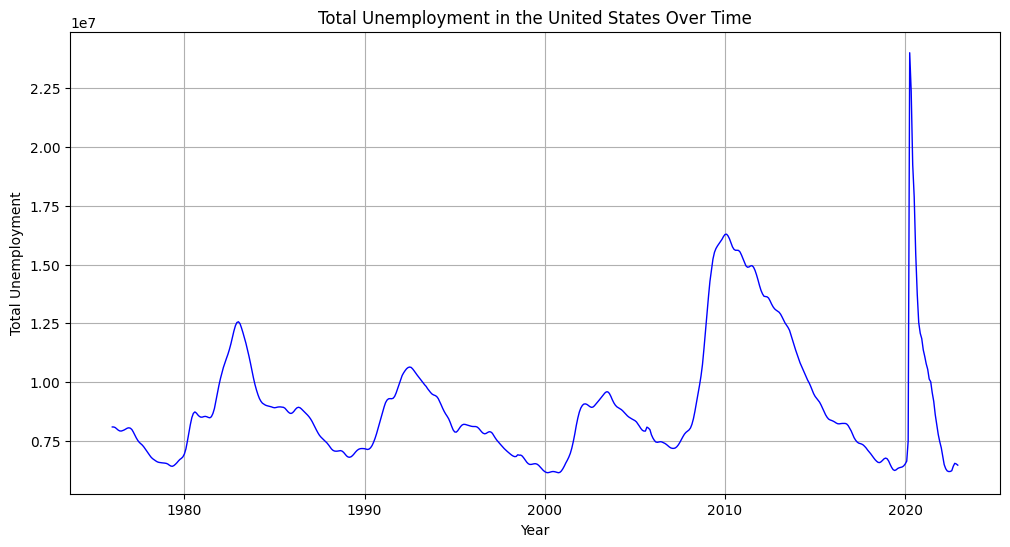

In [53]:
# Creating a line plot for the total unemployment in the US
plt.figure(figsize=(12,6))
plt.plot(us_total_unemployment, color='blue', linestyle='-', linewidth=1)
plt.title('Total Unemployment in the United States Over Time')
plt.xlabel('Year')
plt.ylabel('Total Unemployment')
plt.grid(True)
plt.show()

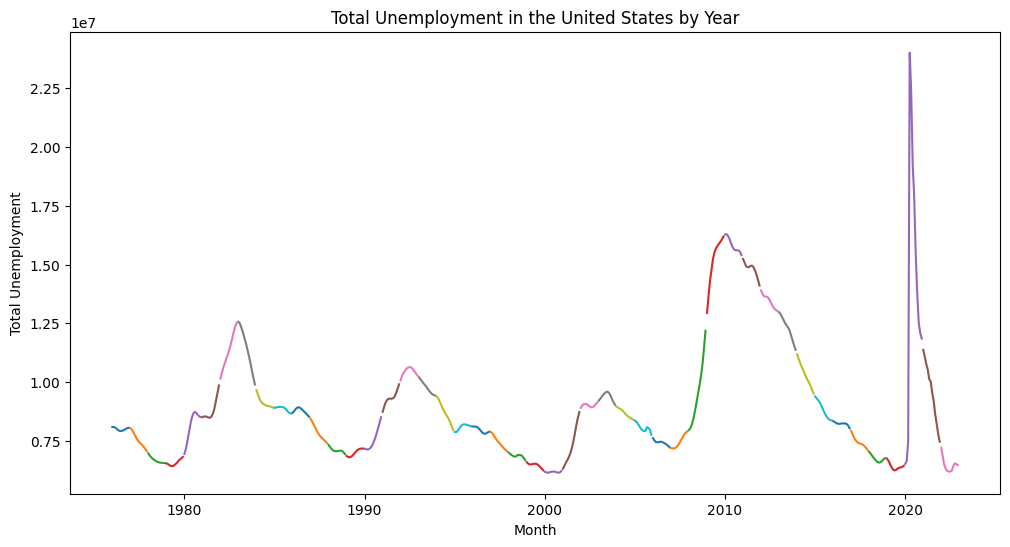

In [54]:
# Extract years from data
years_unemployment = us_total_unemployment.index.year.unique()

# Plotting each year as its own line
plt.figure(figsize=(12,6))
for year in years_unemployment:
  year_data_unemployment = us_total_unemployment[us_total_unemployment.index.year == year]
  plt.plot(year_data_unemployment, label=year)

plt.title('Total Unemployment in the United States by Year')
plt.xlabel('Month')
plt.ylabel('Total Unemployment')
# plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

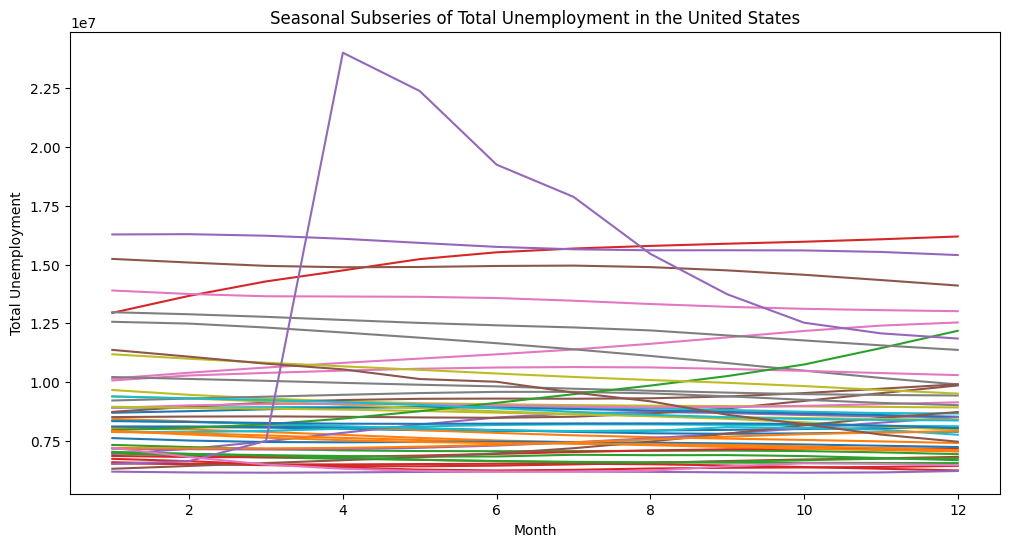

In [55]:
# Calculate total unemployment for the United States by summing across states for each date
us_total_unemployment = df.groupby('Date')['Total Unemployment in State/Area'].sum()

# Plot seasonal subseries
us_total_unemployment_df = us_total_unemployment.reset_index()
us_total_unemployment_df['Year'] = us_total_unemployment_df['Date'].dt.year
us_total_unemployment_df['month'] = us_total_unemployment_df['Date'].dt.month


# Pivot table
table_unemployment = pd.pivot_table(us_total_unemployment_df,
                       values='Total Unemployment in State/Area',
                       index=['month'],
                       columns='Year',
                       aggfunc='sum')

# Plot de series
fig, ax = plt.subplots(figsize=(12,6))
table_unemployment.plot(ax=ax, kind='line', legend=False)
ax.set_xlabel('Month')
ax.set_ylabel('Total Unemployment')
ax.set_title('Seasonal Subseries of Total Unemployment in the United States')
plt.show()

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose

In [57]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10,4)

In [58]:
def plot_series(s, title):
  s.plot()
  plt.title(title)
  plt.xlabel("Time")
  plt.ylabel("Value")
  plt.grid(True)
  plt.show()

def adf_test(x):
  res = adfuller(x, autolag="AIC")
  keys = ['test_stat', 'pvalue', 'lags', 'nobs', 'crit_values', 'icbest']
  return dict(zip(keys,[res[0], res[1], res[3], res[4], res[5]]))

def kpss_test(x, regression='c', nlags="auto"):
  stat, pval, lags, crit = kpss(x, regression=regression, nlags=nlags)
  return {"test_stat": stat, "pvalue": pval, "lags": lags, "crit_values": crit, "regression": regression}

def print_test(x, name="series"):
  print(f"Test {name}")
  a = adf_test(x)
  print(f"ADF Statistic: {a['test_stat']:.3f} p={a['pvalue']}")
  try:
    k = kpss_test(x)
    print(f"KPSS: stat={k['test_stat']:.3f} p={k['pvalue']}")
  except:
    print("KPSS test failed")

def rolling_mean_var(s, window=24, title="Rolling Mean & Var"):
  rolling_mean = s.rolling(window).mean()
  rolling_var = s.rolling(window).var()
  fig, ax = plt.subplots(2, 1, figsize=(10, 6))
  ax[0].plot(s, label="Original")
  ax[0].plot(rolling_mean, label="Rolling Mean")
  ax[0].legend()
  ax[0].set_title(title + "- mean")
  ax[1].plot(rolling_var, label="Rolling Var")
  ax[1].legend()
  ax[1].set_title(title + "- var")
  plt.show()

In [59]:
n = 240  # months
t =  np.arange(n)

# Stationary: white noise
white_noise = pd.Series(np.random.normal(0, 1, n))

trend = 0.02 * t
trended = pd.Series(trend + np.random.normal(0, 1, n))

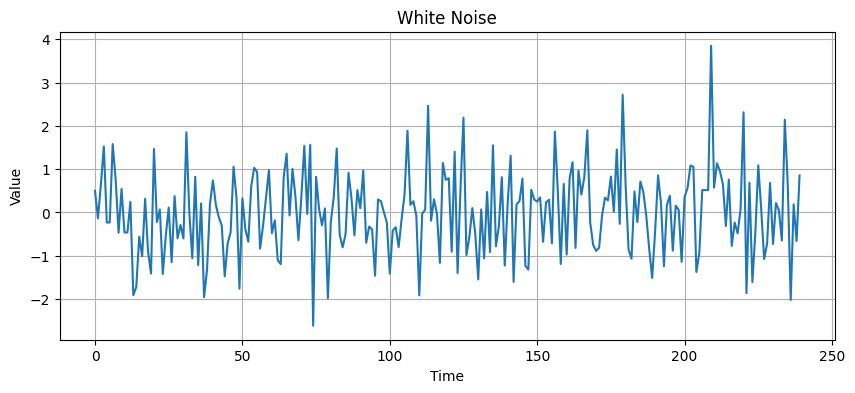

Test White Noise
ADF Statistic: -16.112 p=5.006520467194035e-29
KPSS: stat=0.298 p=0.1


/tmp/ipython-input-1913517918.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, pval, lags, crit = kpss(x, regression=regression, nlags=nlags)


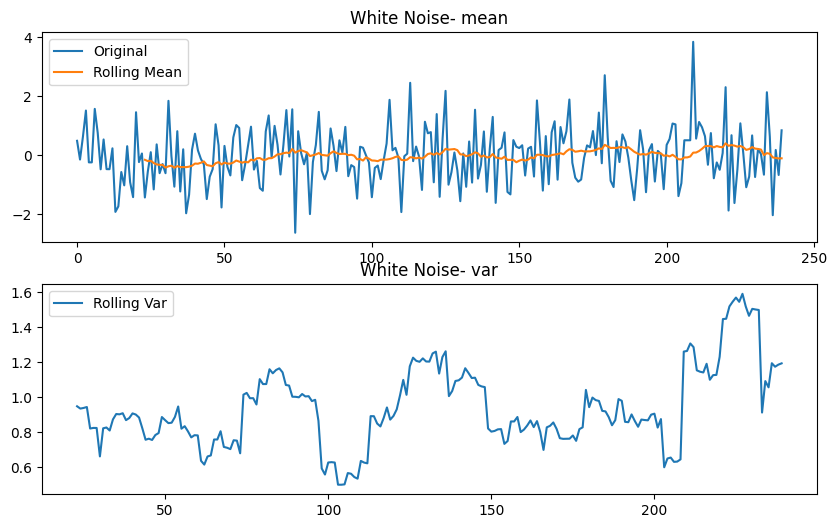

In [60]:
plot_series(white_noise, "White Noise")
print_test(white_noise, "White Noise")
rolling_mean_var(white_noise, window=24, title="White Noise")

La gráfica muestra una serie de ruido blanco, es decir, valores aleatorios que fluctúan sin seguir ningún patrón, tendencia o ciclo. Los puntos parecen dispersos alrededor de una media cercana a cero y presentan variaciones impredecibles de un momento a otro. Este comportamiento refleja que cada valor es independiente del anterior y que no existe estructura temporal, lo cual es característico del ruido blanco.

La gráfica superior muestra la serie de ruido blanco junto con su media móvil. Aunque la serie fluctúa de manera aleatoria, la media móvil se mantiene cerca de cero, lo cual confirma que no existe una tendencia y que el ruido blanco tiene una media constante en el tiempo.

En la gráfica inferior, la varianza móvil también oscila, pero sin patrones definidos. Aunque presenta pequeños tramos con mayor o menor variabilidad, estas fluctuaciones son esperadas debido a la naturaleza aleatoria del ruido blanco. En conjunto, las dos gráficas muestran que el proceso no tiene estructura temporal y mantiene una media y varianza aproximadamente constantes, características típicas del ruido blanco.